In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    recall_score, 
    precision_score,
    f1_score, 
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [7]:
scaler = joblib.load("../Models/scaler.joblib")
model = joblib.load("../Models/xgb_model.joblib")
feature_columns = joblib.load("../Models/feature_columns.joblib")

In [8]:
df = pd.read_csv("../Data/preprocessed.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Average,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,29.850000,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,0,55.573529,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,1,54.075000,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,40.905556,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,75.825000,1,0,0,1,0


In [12]:
x = df.drop(['Churn'], axis=1)
y = df['Churn']

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

xtest = xtest[feature_columns]

In [14]:
scaled_scaled = xtest.copy()
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Average']

scaled_scaled[continuous_cols] = scaler.transform(scaled_scaled[continuous_cols])

In [15]:
y_pred = model.predict(xtest)
y_pred_proba = model.predict_proba(xtest)[:, 1]

In [19]:
accuracy = accuracy_score(ytest, y_pred)
recall = recall_score(ytest, y_pred)
precision = precision_score(ytest, y_pred)
f1 = f1_score(ytest, y_pred)
roc_auc = roc_auc_score(ytest, y_pred_proba)
conf_matrix = confusion_matrix(ytest, y_pred)

In [20]:
evaluation_result = pd.DataFrame([{
    "Model": "XGB Classifier",  # Name of the model
    "Accuracy": accuracy,
    "Recall": recall,
    "Precision": precision,
    "F1 Score": f1,
    "ROC AUC Score": roc_auc,
    "Confusion Matrix": str(conf_matrix)  # Convert to string for clean display
}])

evaluation_result

,Model,Accuracy,Recall,Precision,F1 Score,ROC AUC Score,Confusion Matrix
0,XGB Classifier,0.744847,0.78877,0.513043,0.621707,0.829168,[[753 280]\n [ 79 295]]


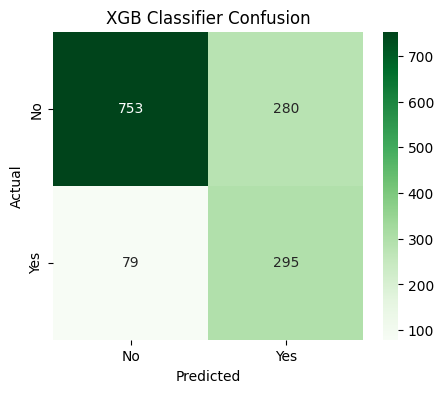

In [23]:
plt.figure(figsize=(5,4))
labels=['No', 'Yes']
sns.heatmap(
    conf_matrix, annot=True, fmt='g', cmap='Greens', 
    xticklabels=labels, yticklabels=labels
)
plt.title('XGB Classifier Confusion')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

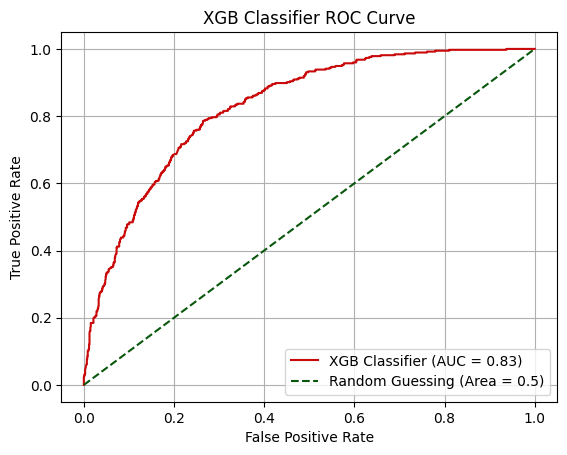

In [27]:
fpr, tpr, _ = roc_curve(ytest, y_pred_proba)

plt.plot(fpr, tpr, color="#CA0A0A", label= f"XGB Classifier (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], color="#08570C", linestyle="--", label="Random Guessing (Area = 0.5)")

plt.title("XGB Classifier ROC Curve")
plt.xlabel("False Positive Rate")   
plt.ylabel("True Positive Rate")      
plt.legend(loc='lower right')        
plt.grid(True)                     
plt.show() 